# Notebook 03: Lake Mead Wildfire Clustering

**Obstacle-aware k-means applied to a long, narrow waterbody**

Notebook 02 established that obstacle-aware k-means produces a modest (~7%) span improvement on the Lake Tahoe basin, but the effect disappears near-shore. We suggested that Tahoe's roughly round geometry doesn't create the kind of clustering ambiguity the boundary parameter is designed to resolve.

This notebook applies the same method to Lake Mead, which has a very different geometry: long, narrow, with multiple major arms (Boulder Basin, the main eastern body, the Overton Arm to the north, and the channel south to Hoover Dam). If the obstacle parameter's value depends on lake shape -- as the Tahoe results suggest -- Mead should respond differently.

Same Tier 1 setup as Tahoe (XY + $s$, no attributes used in the clustering objective). Two scales:

- **Basin scale**: all 844 wildfires within a bounding box around Lake Mead
- **Near-shore scale**: 208 fires within 5 km of the lake's shoreline

The notebook also includes a brief exploratory attribute section, a cross-lake comparison with Tahoe's findings, and saves the data needed for the dashboard built in Notebook 04.

## 1. Setup

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings('ignore', category=IntegrationWarning)
warnings.filterwarnings('ignore', message='.*Intel OpenMP.*')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sqlite3
import pickle
import requests

from shapely.geometry import Polygon as ShapelyPolygon
from shapely.ops import unary_union

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from obstacle_clustering import SplineBoundary, ObstacleKMeans, attribute_separation
from obstacle_clustering.optimization import objective_function

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
})

CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

cache_dir = Path('../data/cached')
cache_dir.mkdir(parents=True, exist_ok=True)


def cached_or_run(cache_path, compute_fn, force_rerun=False):
    """Load from cache if it exists, otherwise run compute_fn and save."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_rerun:
        print(f'Loading cached: {cache_path.name}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print(f'Computing (will cache to {cache_path.name})...')
    result = compute_fn()
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    return result


def arc_length_span(s_values):
    """Arc-length span of a cluster on the loop [0, 1]."""
    if len(s_values) <= 1:
        return 0.0
    sorted_s = np.sort(s_values)
    gaps = np.diff(sorted_s)
    wrap_gap = (1.0 - sorted_s[-1]) + sorted_s[0]
    largest_gap = max(gaps.max(), wrap_gap)
    return 1.0 - largest_gap


def map_labels_to_reference(labels, reference_labels, k):
    """Greedy overlap-based label alignment for consistent cluster colors."""
    overlap = np.zeros((k, k), dtype=int)
    for i in range(k):
        for j in range(k):
            overlap[i, j] = np.sum((labels == i) & (reference_labels == j))

    mapping = {}
    used = set()
    sort_order = np.argsort(-overlap.max(axis=1))
    for i in sort_order:
        for j in np.argsort(-overlap[i]):
            if j not in used:
                mapping[i] = j
                used.add(j)
                break
    return mapping

## 2. Querying the USGS National Hydrography Dataset for Lake Mead

Lake Mead is a reservoir, so it doesn't appear in the NHD's Small-Scale Waterbody layer (layer 10) that we used for Tahoe. We query layer 12 (Waterbody - Large Scale, 1:24,000 resolution), which contains reservoirs.

The query returns multiple features named "Lake Mead" (some are small disconnected polygons in other states). We pick the largest by area, which is the actual reservoir in Nevada/Arizona.

In [2]:
NHD_WATERBODY_URL = (
    "https://hydro.nationalmap.gov/arcgis/rest/services/nhd/MapServer/12/query"
)

params = {
    'where': "GNIS_NAME = 'Lake Mead'",
    'outFields': 'GNIS_NAME,AREASQKM,ELEVATION,REACHCODE',
    'returnGeometry': 'true',
    'outSR': 4326,
    'f': 'json',
}

response = requests.get(NHD_WATERBODY_URL, params=params)
response.raise_for_status()
data = response.json()

n_features = len(data['features'])
print(f'Features returned: {n_features}')

for feat in data['features']:
    attrs = feat['attributes']
    print(f"  Name: {attrs['GNIS_NAME']}, "
          f"Area: {attrs['AREASQKM']:.1f} sq km, "
          f"Reach: {attrs['REACHCODE']}")

Features returned: 5
  Name: Lake Mead, Area: 0.0 sq km, Reach: 01100006001704
  Name: Lake Mead, Area: 541.3 sq km, Reach: 15010005009521
  Name: Lake Mead, Area: 0.1 sq km, Reach: 10090206001013
  Name: Lake Mead, Area: 0.7 sq km, Reach: 15010014003280
  Name: Lake Mead, Area: 7.2 sq km, Reach: 15010006010760


### Extracting Boundary Coordinates

In [3]:
# NHD splits Lake Mead across multiple HUC8 boundaries. Union all the
# features above 1 sq km to get the full lake 
polygons = [
    ShapelyPolygon(max(f['geometry']['rings'], key=len))
    for f in data['features']
    if f['attributes']['AREASQKM'] > 1.0
]
print(f'Unioning {len(polygons)} NHD polygons...')

unified = unary_union(polygons)
coords = np.array(unified.exterior.coords)

lon = coords[:, 0]
lat = coords[:, 1]

print(f'Exterior ring: {len(lon)} vertices')
print(f'Longitude range: [{lon.min():.4f}, {lon.max():.4f}]')
print(f'Latitude range:  [{lat.min():.4f}, {lat.max():.4f}]')

Unioning 2 NHD polygons...
Exterior ring: 74403 vertices
Longitude range: [-114.8748, -113.7790]
Latitude range:  [35.9945, 36.5378]


## 3. Cleaning the Boundary

Lake Mead's raw NHD polygon has ~73,000 vertices (compared to Tahoe's ~6,000) because the lake's complex shoreline is sampled finely at the 1:24,000 resolution. We simplify with a tolerance of 0.005 degrees (~450 m at this latitude), which reduces vertex count to a few hundred while preserving the major arms.

Lake Mead doesn't have a Tahoe-Keys analog to clip out; we just apply simplification.

Vertices before simplification: 74403
Vertices after simplification:  418


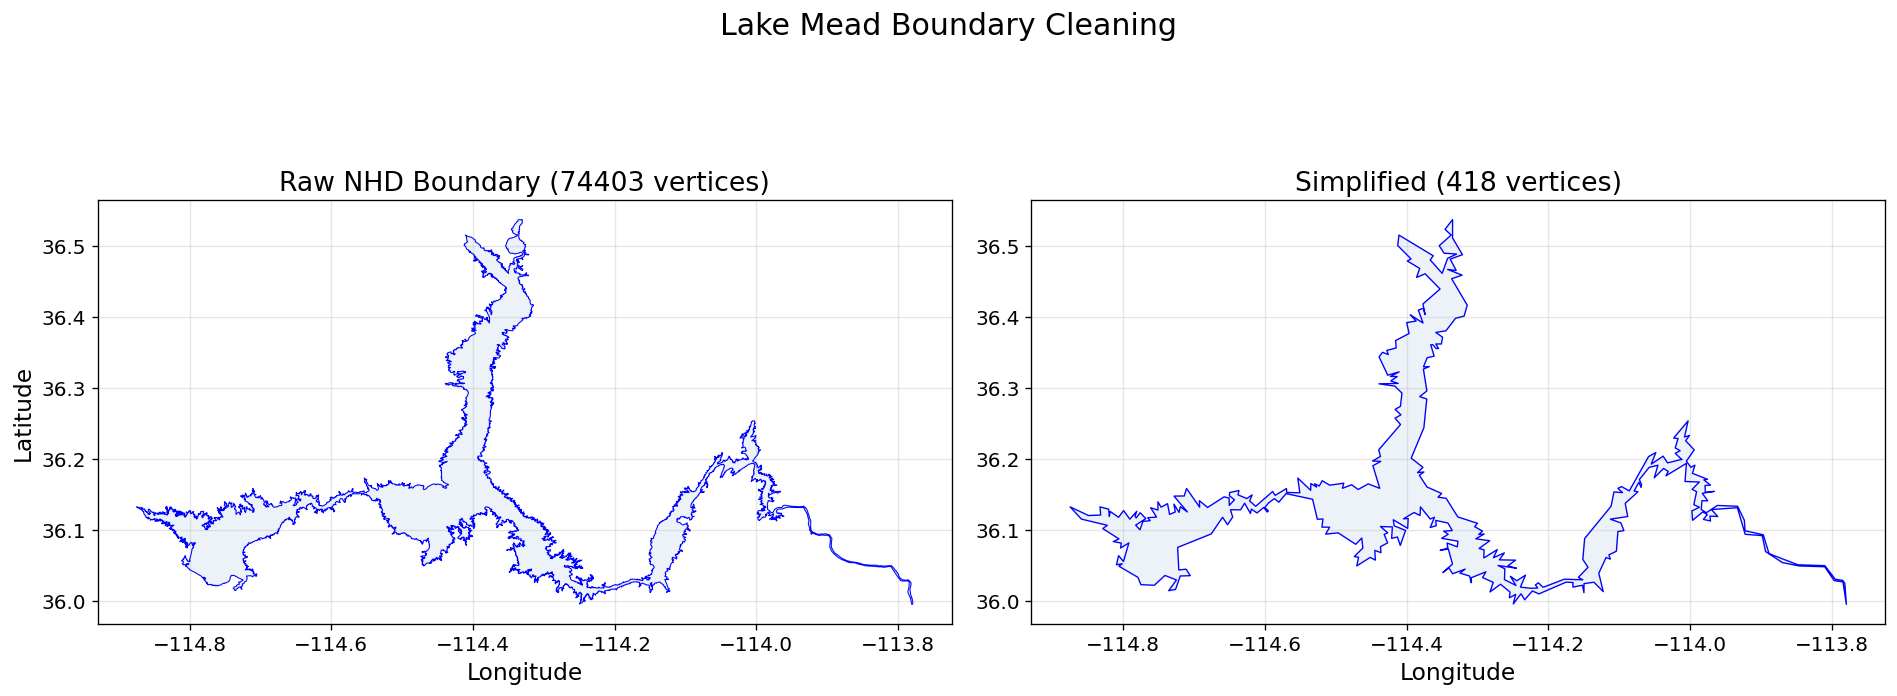


Using simplified boundary downstream (418 vertices).


In [4]:
raw_polygon = ShapelyPolygon(zip(lon, lat))

tolerance = 0.005  # ~450 m at this latitude
simplified = raw_polygon.simplify(tolerance, preserve_topology=True)

simple_coords = np.array(simplified.exterior.coords)
lon_simple = simple_coords[:, 0]
lat_simple = simple_coords[:, 1]

print(f'Vertices before simplification: {len(lon)}')
print(f'Vertices after simplification:  {len(lon_simple)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(lon, lat, 'b-', linewidth=0.6)
ax.fill(lon, lat, alpha=0.1, color='steelblue')
ax.set_title(f'Raw NHD Boundary ({len(lon)} vertices)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(lon_simple, lat_simple, 'b-', linewidth=0.8)
ax.fill(lon_simple, lat_simple, alpha=0.1, color='steelblue')
ax.set_title(f'Simplified ({len(lon_simple)} vertices)')
ax.set_xlabel('Longitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.suptitle('Lake Mead Boundary Cleaning', y=1.02)
plt.tight_layout()
plt.show()

lon = lon_simple
lat = lat_simple
print(f'\nUsing simplified boundary downstream ({len(lon)} vertices).')

### Saving Boundary Coordinates

In [5]:
boundary_dir = Path('../data/boundaries')
boundary_dir.mkdir(parents=True, exist_ok=True)
boundary_path = boundary_dir / 'mead_boundary.csv'

boundary_df = pd.DataFrame({'longitude': lon, 'latitude': lat})
boundary_df.to_csv(boundary_path, index=False)

print(f'Saved {len(boundary_df)} boundary points to {boundary_path}')

Saved 418 boundary points to ..\data\boundaries\mead_boundary.csv


## 4. Fitting the Spline Boundary

Total arc length: 6.8697 degrees
Parameter range: (0.0, 1.0)


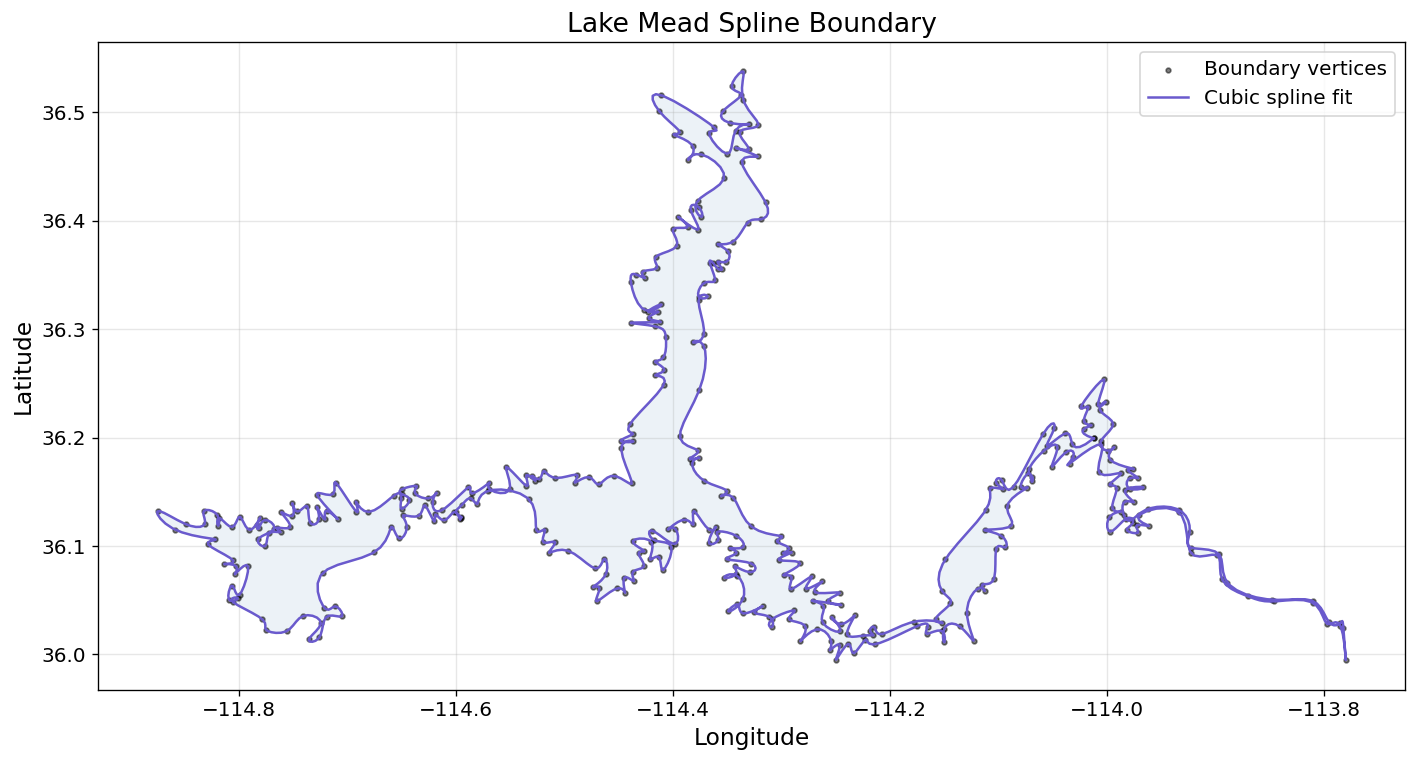

In [6]:
boundary = SplineBoundary(x_coords=lon, y_coords=lat)

L = boundary.total_arc_length()
print(f'Total arc length: {L:.4f} degrees')
print(f'Parameter range: {boundary.t_range()}')

# Sample the spline for visualization
spline_pts = boundary.sample_boundary(n_points=2000)

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(lon, lat, c='black', s=8, alpha=0.5, zorder=2,
           label='Boundary vertices')
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='slateblue', linewidth=1.5,
        zorder=3, label='Cubic spline fit')
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Lake Mead Spline Boundary')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Loading Wildfire Data

We pull fires from FPA FOD within a bounding box around Lake Mead. Unlike the Tahoe analysis, there's no official basin polygon to clip to -- the Lake Mead National Recreation Area covers a much larger area including Lake Mohave downstream. We just use the bounding box, which captures fires within roughly 20 km of any part of the lake.

In [7]:
# Bounding box around Lake Mead
LAT_MIN, LAT_MAX = 35.8, 36.6
LON_MIN, LON_MAX = -115.0, -113.7

db_path = '../data/raw/fires.sqlite'

query = """
    SELECT LATITUDE, LONGITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
           NWCG_CAUSE_CLASSIFICATION, FIRE_YEAR, DISCOVERY_DOY
    FROM Fires
    WHERE LATITUDE BETWEEN ? AND ?
      AND LONGITUDE BETWEEN ? AND ?
"""

with sqlite3.connect(db_path) as conn:
    fires_raw = pd.read_sql_query(
        query, conn,
        params=(LAT_MIN, LAT_MAX, LON_MIN, LON_MAX),
    )

print(f'Fires in SQL bounding box: {len(fires_raw)}')
print(f'Year range: {fires_raw["FIRE_YEAR"].min()}-{fires_raw["FIRE_YEAR"].max()}')
print(f'\nCause breakdown:')
print(fires_raw['NWCG_GENERAL_CAUSE'].value_counts().to_string())

Fires in SQL bounding box: 1059
Year range: 1992-2020

Cause breakdown:
NWCG_GENERAL_CAUSE
Natural                                       493
Missing data/not specified/undetermined       215
Equipment and vehicle use                     102
Recreation and ceremony                        64
Debris and open burning                        45
Fireworks                                      36
Arson/incendiarism                             35
Smoking                                        31
Firearms and explosives use                    21
Misuse of fire by a minor                      10
Other causes                                    4
Power generation/transmission/distribution      2
Railroad operations and maintenance             1


## 6. Cleaning and Feature Engineering

Same recipe as Tahoe: drop missing-cause fires, binary-encode cause, log-transform fire size.

Notice Mead's cause distribution is roughly the opposite of Tahoe's -- here lightning-caused (Natural) fires dominate, while Tahoe was overwhelmingly human-caused. This reflects the difference in surroundings: Mead is in the sparsely populated Mojave Desert, while Tahoe has heavy recreational use around the lake's shoreline.

In [8]:
# Drop missing-cause fires
fires = fires_raw[
    fires_raw['NWCG_GENERAL_CAUSE'] != 'Missing data/not specified/undetermined'
].copy().reset_index(drop=True)

print(f'Fires after filtering missing cause: {len(fires)}')

# Encode cause as binary
fires['cause_binary'] = (fires['NWCG_GENERAL_CAUSE'] != 'Natural').astype(int)

# Log-transform fire size
fires['fire_size_log'] = np.log1p(fires['FIRE_SIZE'].values)

print(f'\nCause classification:')
print(f"  Natural (lightning): {(fires['cause_binary'] == 0).sum()}")
print(f"  Human-caused:        {(fires['cause_binary'] == 1).sum()}")

print(f'\nFire size (acres):')
print(f"  Min:    {fires['FIRE_SIZE'].min():.4f}")
print(f"  Median: {fires['FIRE_SIZE'].median():.2f}")
print(f"  Mean:   {fires['FIRE_SIZE'].mean():.2f}")
print(f"  Max:    {fires['FIRE_SIZE'].max():.2f}")

Fires after filtering missing cause: 844

Cause classification:
  Natural (lightning): 493
  Human-caused:        351

Fire size (acres):
  Min:    0.1000
  Median: 0.10
  Mean:   484.55
  Max:    44707.00


## 7. Projecting Fires onto the Lake Boundary

In [9]:
def project_all_fires():
    print('Projecting fire locations onto lake boundary...')
    lons = fires['LONGITUDE'].values
    lats = fires['LATITUDE'].values
    n = len(fires)

    t_arr = np.zeros(n)
    s_arr = np.zeros(n)
    for idx in range(n):
        if idx % 200 == 0:
            print(f'  {idx}/{n} ({100*idx/n:.0f}%)')
        t_arr[idx], s_arr[idx] = boundary.project_point(lons[idx], lats[idx])
    return t_arr, s_arr


t_values, s_values = cached_or_run(
    cache_dir / 'mead_fire_projections.pkl',
    project_all_fires,
)

fires['t_param'] = t_values
fires['s_param'] = s_values

print(f'Projection complete: {len(fires)} fires projected')

Loading cached: mead_fire_projections.pkl
Projection complete: 844 fires projected


## 8. Feature Matrix

Same structure as Tahoe: scaled XY in columns 0-1, $s$ in column 2, scaled log fire size in column 3, cause binary in column 4. Tier 1 clustering uses only columns 0-2.

In [10]:
scaler_xy = MinMaxScaler()
xy_scaled = scaler_xy.fit_transform(fires[['LONGITUDE', 'LATITUDE']].values)

scaler_size = MinMaxScaler()
fire_size_scaled = scaler_size.fit_transform(fires[['fire_size_log']].values)

X = np.column_stack([
    xy_scaled,
    fires['s_param'].values,
    fire_size_scaled.ravel(),
    fires['cause_binary'].values
])

feature_names = ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (844, 5)


## 9. Visualizing the Raw Data

Before clustering, see the fires laid out against the lake boundary. The visual should make it intuitive whether $s$ would be useful here -- specifically, whether fires on opposing shores are close in $(x, y)$ but separated by water.

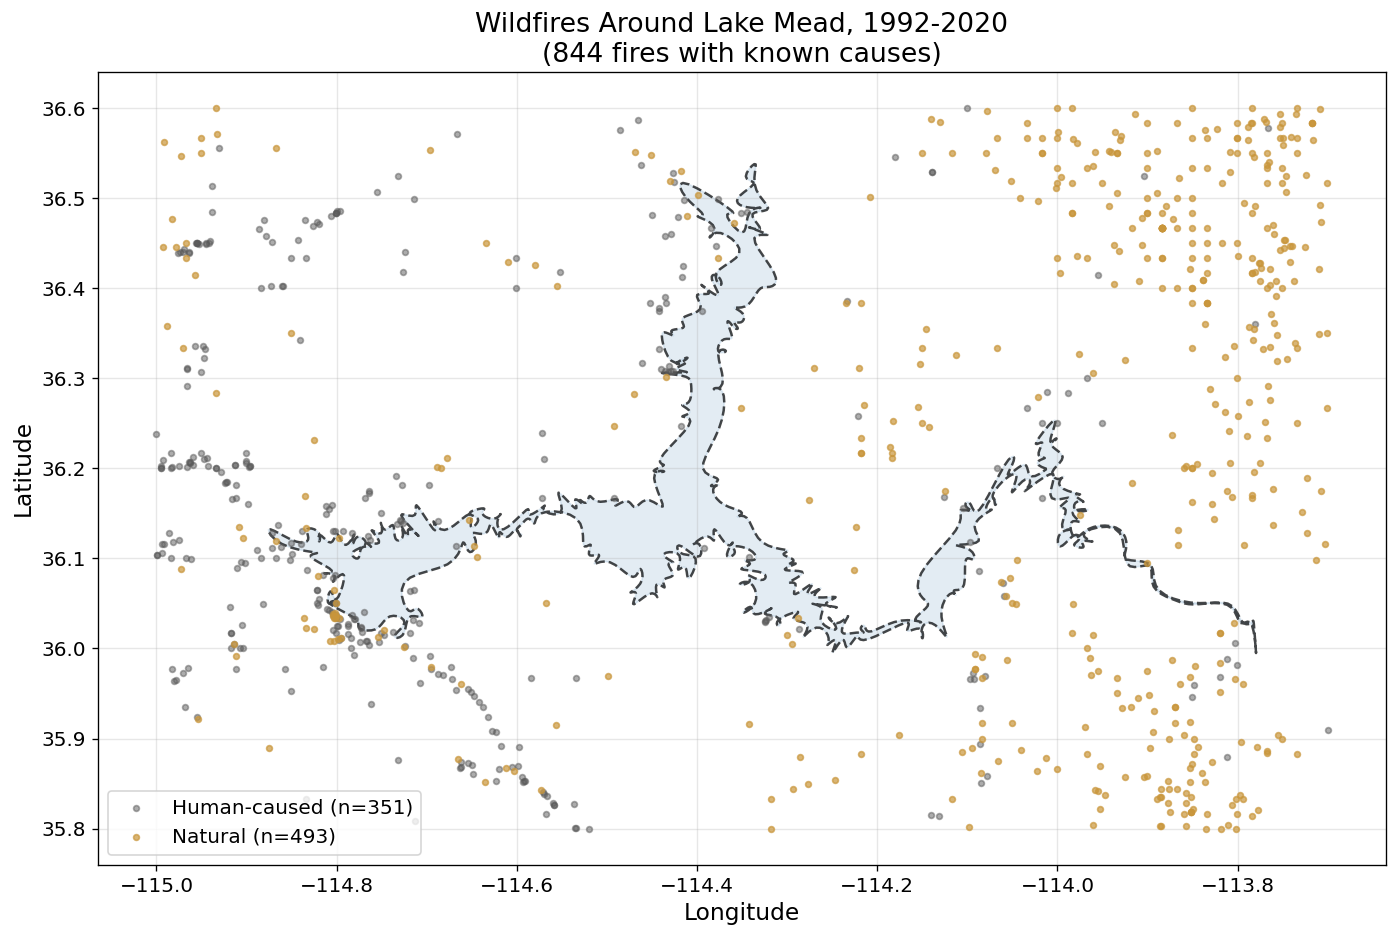

In [11]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

human = fires['cause_binary'] == 1
natural = ~human
ax.scatter(fires.loc[human, 'LONGITUDE'], fires.loc[human, 'LATITUDE'],
           c='#5a5a5a', s=12, alpha=0.5,
           label=f'Human-caused (n={human.sum()})', zorder=2)
ax.scatter(fires.loc[natural, 'LONGITUDE'], fires.loc[natural, 'LATITUDE'],
           c='#c9963b', s=12, alpha=0.7,
           label=f'Natural (n={natural.sum()})', zorder=3)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Wildfires Around Lake Mead, {fires["FIRE_YEAR"].min()}-{fires["FIRE_YEAR"].max()}'
             f'\n({len(fires)} fires with known causes)')
ax.legend(loc='best')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Basin-Scale Clustering: Standard k-Means Baseline

In [12]:
k = 4

kmeans_basin = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_basin_std = kmeans_basin.fit_predict(X[:, :2])

spans_basin_std = [
    arc_length_span(fires['s_param'].values[labels_basin_std == c])
    for c in range(k)
]

print(f'Standard k-Means converged in {kmeans_basin.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_std == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_std):.4f}')

Standard k-Means converged in 7 iterations

Cluster sizes:
  Cluster 1: 185 fires
  Cluster 2: 124 fires
  Cluster 3: 273 fires
  Cluster 4: 262 fires

Mean arc-length span: 0.3412


c:\Users\mpp24\anaconda3\envs\obstacle-clustering\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


## 11. Basin-Scale Clustering: Obstacle-Aware k-Means at Equal Weights

In [13]:
model_basin_eq = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,
    random_state=42, n_attr=0
)
model_basin_eq.fit(X[:, :3], t_data=fires['t_param'].values)
labels_basin_eq = model_basin_eq.labels_

spans_basin_eq = [
    arc_length_span(fires['s_param'].values[labels_basin_eq == c])
    for c in range(k)
]

print(f'OA equal weights: converged in {model_basin_eq.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_eq == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_eq):.4f}')

OA equal weights: converged in 9 iterations

Cluster sizes:
  Cluster 1: 274 fires
  Cluster 2: 262 fires
  Cluster 3: 124 fires
  Cluster 4: 184 fires

Mean arc-length span: 0.3412


## 12. Basin-Scale Clustering: Obstacle-Aware k-Means at Optimized $\beta$

Same grid search as Tahoe. The Mead objective surface has a noticeably different shape from Tahoe's -- worth looking at the $J$ / span plot carefully.

In [14]:
def compute_mead_basin_beta_sweep():
    print('Computing Mead basin objective surface (1D beta sweep)...')
    n_grid = 30
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    J_vals = np.zeros(n_grid)
    for i, b in enumerate(beta_vals):
        J_vals[i] = objective_function(
            (1.0, b, 0.0),
            X[:, :3], fires['t_param'].values, boundary,
            k=k, n_attr=0, attr_indices=[], random_state=42
        )
    return beta_vals, J_vals


beta_grid_basin, J_vals_basin = cached_or_run(
    cache_dir / 'mead_beta_sweep.pkl',
    compute_mead_basin_beta_sweep,
)

i_min_basin = J_vals_basin.argmin()
j_min_beta_basin = beta_grid_basin[i_min_basin]
j_min_J_basin = J_vals_basin[i_min_basin]

print(f'J-minimum on grid: beta = {j_min_beta_basin:.4f}, J = {j_min_J_basin:.4f}')

Computing (will cache to mead_beta_sweep.pkl)...
Computing Mead basin objective surface (1D beta sweep)...
J-minimum on grid: beta = 1.5293, J = 1.0407


### $J$ and Span Across $\beta$ (Basin)

For Lake Mead, $J$ is approximately flat over a wide range of $\beta$ values, while the span continues to decrease past $\beta = 1$. When $J$ has a flat region, multiple clusterings are equivalent under the optimizer, so we have some freedom in choosing $\beta$ within that range. We pick $\beta$ within the flat region that gives the lowest span, which is the metric most directly tied to obstacle awareness.

Computing (will cache to mead_basin_spans_by_beta.pkl)...
Computing Mead basin mean span at each beta...


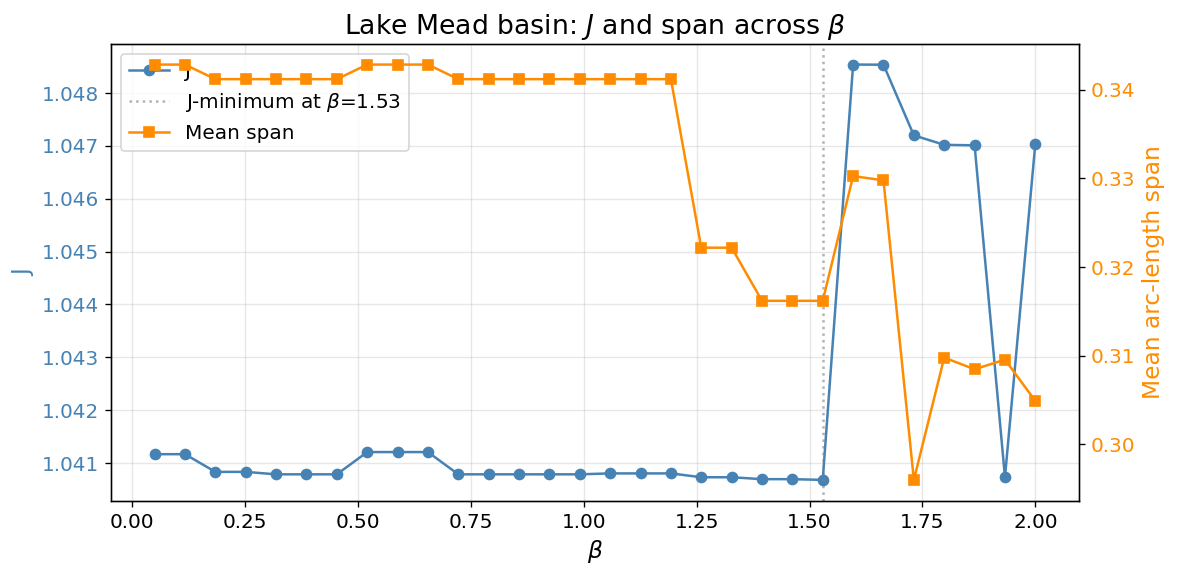

In [15]:
def compute_mead_basin_spans_by_beta():
    print('Computing Mead basin mean span at each beta...')
    spans = []
    for b in beta_grid_basin:
        model_b = ObstacleKMeans(
            k=k, boundary=boundary,
            alpha=1.0, beta=b, gamma=0.0,
            random_state=42, n_attr=0
        )
        model_b.fit(X[:, :3], t_data=fires['t_param'].values)
        spans_b = [
            arc_length_span(fires['s_param'].values[model_b.labels_ == c])
            for c in range(k)
        ]
        spans.append(np.mean(spans_b))
    return np.array(spans)


spans_by_beta_basin = cached_or_run(
    cache_dir / 'mead_basin_spans_by_beta.pkl',
    compute_mead_basin_spans_by_beta,
)


fig, ax1 = plt.subplots(figsize=(10, 5))

color_J = 'steelblue'
ax1.plot(beta_grid_basin, J_vals_basin, 'o-', color=color_J, label='J')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel('J', color=color_J)
ax1.tick_params(axis='y', labelcolor=color_J)

ax2 = ax1.twinx()
color_span = 'darkorange'
ax2.plot(beta_grid_basin, spans_by_beta_basin, 's-', color=color_span,
         label='Mean span')
ax2.set_ylabel('Mean arc-length span', color=color_span)
ax2.tick_params(axis='y', labelcolor=color_span)

ax1.axvline(j_min_beta_basin, color='gray', linestyle=':', alpha=0.6,
            label=rf'J-minimum at $\beta$={j_min_beta_basin:.2f}')

ax1.set_title(r'Lake Mead basin: $J$ and span across $\beta$')
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

### Selecting $\beta$ and Refitting (Basin)

The $J$ surface is flat from roughly $\beta = 0.5$ onwards, so the optimizer's grid minimum is essentially arbitrary within that range. The span curve, on the other hand, continues to decrease until it stabilizes near $\beta = 1.5$ to $2.0$. We pick $\beta = 1.85$, which sits comfortably inside the flat $J$ region and gives the largest span improvement.

In [16]:
# Selected based on the J / span plot above.
# Mead basin: J is flat for beta > 0.5; span keeps decreasing through this
# region. We pick beta = 1.85, which is in the flat J region and gives the
# largest span improvement.
opt_beta_basin = 1.8

model_basin_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_basin, gamma=0.0,
    random_state=42, n_attr=0
)
model_basin_opt.fit(X[:, :3], t_data=fires['t_param'].values)
labels_basin_opt = model_basin_opt.labels_

spans_basin_opt = [
    arc_length_span(fires['s_param'].values[labels_basin_opt == c])
    for c in range(k)
]

print(f'Selected beta: {opt_beta_basin}')
print(f'(J-minimum on grid was at beta = {j_min_beta_basin:.4f})')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_opt == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_opt):.4f}')

Selected beta: 1.8
(J-minimum on grid was at beta = 1.5293)

Cluster sizes:
  Cluster 1: 254 fires
  Cluster 2: 180 fires
  Cluster 3: 110 fires
  Cluster 4: 300 fires

Mean arc-length span: 0.3098


## 13. Aligning Cluster Labels and Plotting the Basin Comparison

In [17]:
# Standard k-means is the reference labeling for the basin
labels_basin_std_aligned = labels_basin_std

eq_to_std_basin = map_labels_to_reference(labels_basin_eq, labels_basin_std, k)
labels_basin_eq_aligned = np.array(
    [eq_to_std_basin[l] for l in labels_basin_eq]
)

opt_to_std_basin = map_labels_to_reference(labels_basin_opt, labels_basin_std, k)
labels_basin_opt_aligned = np.array(
    [opt_to_std_basin[l] for l in labels_basin_opt]
)

print('Labels aligned: equal-weight and optimized clusters now share IDs')
print('with the standard k-means baseline.')

Labels aligned: equal-weight and optimized clusters now share IDs
with the standard k-means baseline.


### Side-by-Side Comparison (Basin)

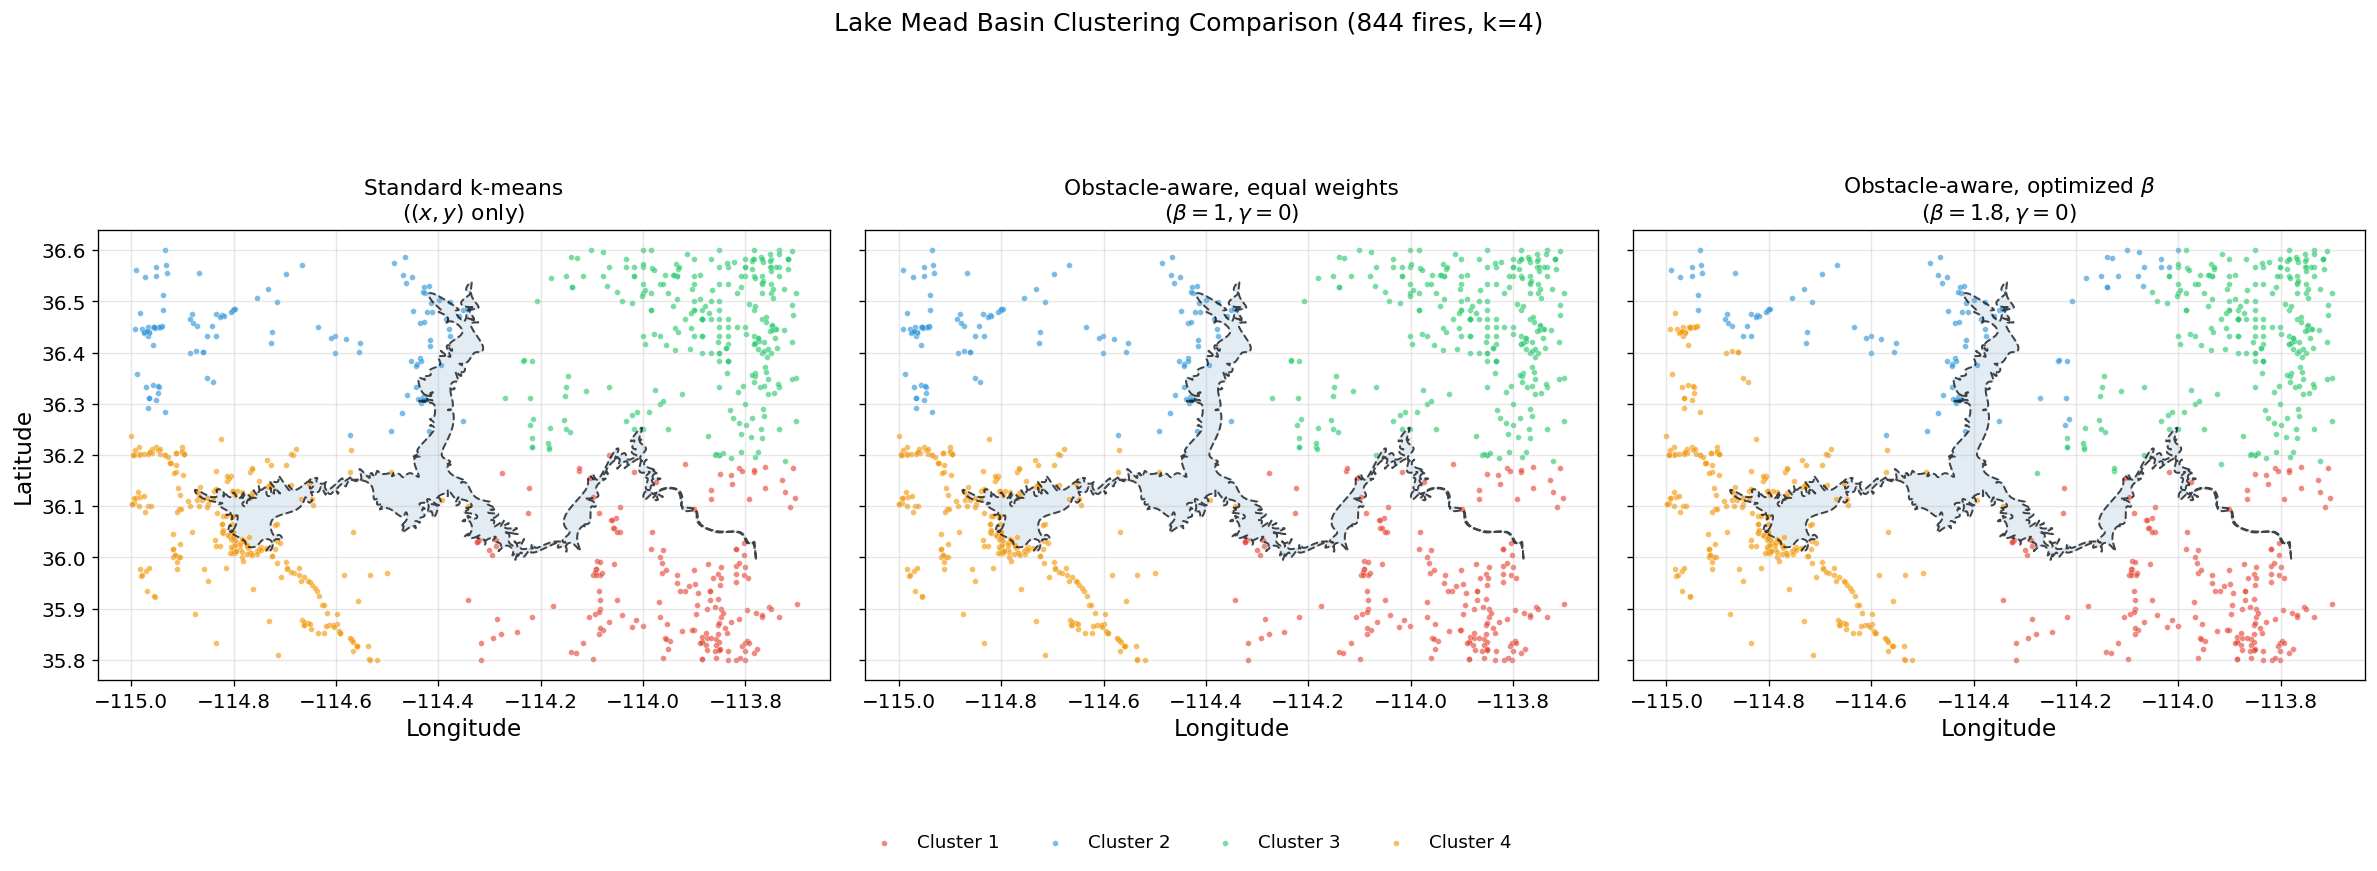

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=True, sharey=True)

for ax, labels, title in [
    (axes[0], labels_basin_std_aligned, 'Standard k-means\n($(x, y)$ only)'),
    (axes[1], labels_basin_eq_aligned,
     r'Obstacle-aware, equal weights' + '\n' + r'($\beta = 1, \gamma = 0$)'),
    (axes[2], labels_basin_opt_aligned,
     r'Obstacle-aware, optimized $\beta$' + '\n' +
     rf'($\beta = {opt_beta_basin}, \gamma = 0$)'),
]:
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.2, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

    for i in range(k):
        mask = labels == i
        ax.scatter(fires['LONGITUDE'].values[mask],
                   fires['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[i], s=12, alpha=0.65,
                   label=f'Cluster {i+1}', edgecolors='white', linewidth=0.2)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Latitude')

handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=k,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11)

fig.suptitle(f'Lake Mead Basin Clustering Comparison ({len(fires)} fires, k={k})',
             fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

### Basin Comparison Statistics

In [19]:
span_pct_eq_basin = (
    100 * (np.mean(spans_basin_std) - np.mean(spans_basin_eq))
    / np.mean(spans_basin_std)
)
span_pct_opt_basin = (
    100 * (np.mean(spans_basin_std) - np.mean(spans_basin_opt))
    / np.mean(spans_basin_std)
)

print(f'Lake Mead basin clustering comparison ({len(fires)} fires):')
print()
print(f'  Standard k-Means on scaled XY:')
print(f'    span = {np.mean(spans_basin_std):.4f}')
print()
print(f'  Obstacle-aware, equal weights (beta = 1, gamma = 0):')
print(f'    span = {np.mean(spans_basin_eq):.4f}')
print(f'    vs standard: span {span_pct_eq_basin:+.1f}%')
print()
print(f'  Obstacle-aware, optimized beta = {opt_beta_basin}:')
print(f'    span = {np.mean(spans_basin_opt):.4f}')
print(f'    vs standard: span {span_pct_opt_basin:+.1f}%')

Lake Mead basin clustering comparison (844 fires):

  Standard k-Means on scaled XY:
    span = 0.3412

  Obstacle-aware, equal weights (beta = 1, gamma = 0):
    span = 0.3412
    vs standard: span +0.0%

  Obstacle-aware, optimized beta = 1.8:
    span = 0.3098
    vs standard: span +9.2%


## 14. Near-Shore Subset

Same approach as Tahoe but with a 5 km threshold instead of 2 km. Lake Mead is much larger than Tahoe (~640 sq km vs. ~500 sq km, but with much longer shoreline), so 5 km is roughly proportional to Tahoe's 2 km in terms of "fraction of fires near the obstacle."

Comparing thresholds across lakes is inherently a judgment call. 5 km also gives us a near-shore subset (~214 fires) large enough for stable k=4 clustering.

In [20]:
# Distance from each fire to its boundary projection
distances_to_lake_km = np.zeros(len(fires))
for i, t in enumerate(fires['t_param'].values):
    proj = boundary.evaluate(t)
    lon_diff = fires['LONGITUDE'].iloc[i] - proj[0]
    lat_diff = fires['LATITUDE'].iloc[i] - proj[1]
    # At latitude ~36, 1 deg lat ~= 111 km, 1 deg lon ~= 90 km
    distances_to_lake_km[i] = np.sqrt((lon_diff * 90)**2 + (lat_diff * 111)**2)

fires['dist_to_lake_km'] = distances_to_lake_km

print('Fire distance distribution (km from Lake Mead shore):')
for thr in [1, 2, 5, 10]:
    n = (fires['dist_to_lake_km'] < thr).sum()
    print(f'  Within {thr:2d} km: {n:4d} fires ({100*n/len(fires):.1f}%)')

# 5 km threshold
threshold_km = 5
near_mask = fires['dist_to_lake_km'].values < threshold_km
n_near = int(near_mask.sum())

print(f'\nNear-shore subset: {n_near} fires within {threshold_km} km of shore')
print(f'  ~{n_near/k:.0f} fires per cluster at k={k}')

X_near = X[near_mask]
t_near = fires['t_param'].values[near_mask]
s_near = fires['s_param'].values[near_mask]
fires_near = fires[near_mask].copy().reset_index(drop=True)

Fire distance distribution (km from Lake Mead shore):
  Within  1 km:   99 fires (11.7%)
  Within  2 km:  137 fires (16.2%)
  Within  5 km:  214 fires (25.4%)
  Within 10 km:  304 fires (36.0%)

Near-shore subset: 214 fires within 5 km of shore
  ~54 fires per cluster at k=4


## 15. Near-Shore Clustering: Three Methods

### 15.1 Standard k-Means (Near-Shore)

In [21]:
kmeans_near = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_near_std = kmeans_near.fit_predict(X_near[:, :2])

spans_near_std = [arc_length_span(s_near[labels_near_std == c]) for c in range(k)]

print(f'Standard k-Means on near-shore subset:')
print(f'  Converged in {kmeans_near.n_iter_} iterations')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_std == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_near_std):.4f}')

Standard k-Means on near-shore subset:
  Converged in 3 iterations
  Cluster 1: 126 fires
  Cluster 2: 16 fires
  Cluster 3: 40 fires
  Cluster 4: 32 fires
  Mean arc-length span: 0.2425


### 15.2 Obstacle-Aware k-Means at Equal Weights (Near-Shore)

In [22]:
model_near_eq = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,
    random_state=42, n_attr=0
)
model_near_eq.fit(X_near[:, :3], t_data=t_near)
labels_near_eq = model_near_eq.labels_

spans_near_eq = [arc_length_span(s_near[labels_near_eq == c]) for c in range(k)]

print(f'OA equal weights on near-shore subset:')
print(f'  Converged in {model_near_eq.n_iter_} iterations')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_eq == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_near_eq):.4f}')

OA equal weights on near-shore subset:
  Converged in 8 iterations
  Cluster 1: 33 fires
  Cluster 2: 126 fires
  Cluster 3: 40 fires
  Cluster 4: 15 fires
  Mean arc-length span: 0.2204


### 15.3 Obstacle-Aware k-Means at Optimized $\beta$ (Near-Shore)

In [23]:
def compute_mead_nearshore_beta_sweep():
    print('Computing Mead near-shore objective surface (1D beta sweep)...')
    n_grid = 30
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    J_vals = np.zeros(n_grid)
    for i, b in enumerate(beta_vals):
        J_vals[i] = objective_function(
            (1.0, b, 0.0),
            X_near[:, :3], t_near, boundary,
            k=k, n_attr=0, attr_indices=[], random_state=42
        )
    return beta_vals, J_vals


beta_grid_near, J_vals_near = cached_or_run(
    cache_dir / 'mead_nearshore_beta_sweep.pkl',
    compute_mead_nearshore_beta_sweep,
)

i_min_near = J_vals_near.argmin()
j_min_beta_near = beta_grid_near[i_min_near]
j_min_J_near = J_vals_near[i_min_near]

print(f'J-minimum on grid: beta = {j_min_beta_near:.4f}, J = {j_min_J_near:.4f}')

Computing (will cache to mead_nearshore_beta_sweep.pkl)...
Computing Mead near-shore objective surface (1D beta sweep)...
J-minimum on grid: beta = 0.5879, J = 1.0155


### $J$ and Span Across $\beta$ (Near-Shore)

Computing (will cache to mead_nearshore_spans_by_beta.pkl)...
Computing Mead near-shore mean span at each beta...


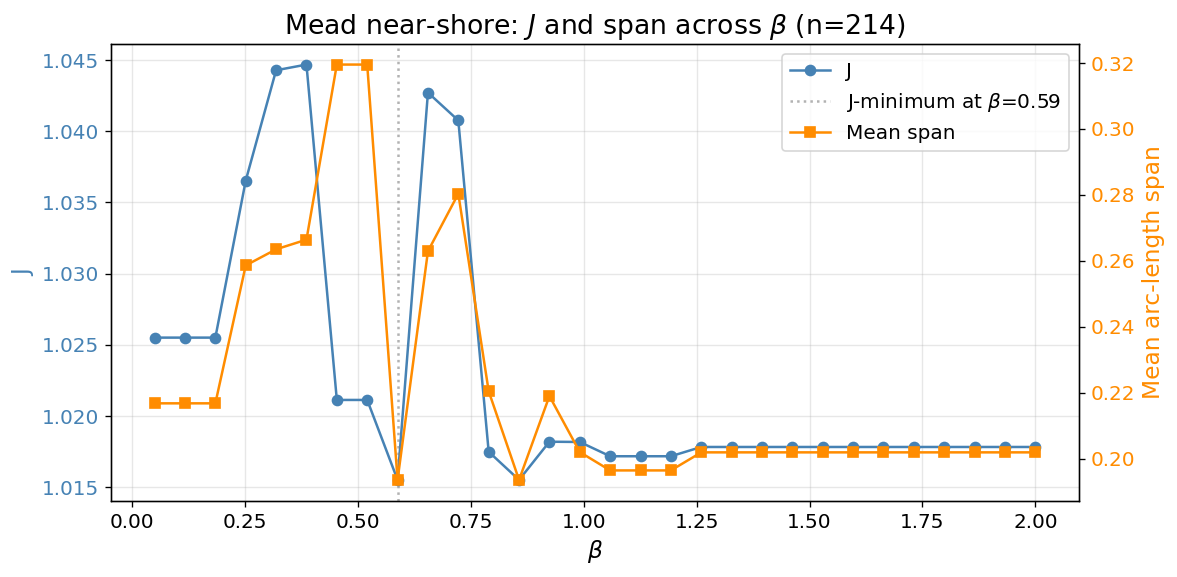

In [24]:
def compute_mead_nearshore_spans_by_beta():
    print('Computing Mead near-shore mean span at each beta...')
    spans = []
    for b in beta_grid_near:
        model_b = ObstacleKMeans(
            k=k, boundary=boundary,
            alpha=1.0, beta=b, gamma=0.0,
            random_state=42, n_attr=0
        )
        model_b.fit(X_near[:, :3], t_data=t_near)
        spans_b = [arc_length_span(s_near[model_b.labels_ == c]) for c in range(k)]
        spans.append(np.mean(spans_b))
    return np.array(spans)


spans_by_beta_near = cached_or_run(
    cache_dir / 'mead_nearshore_spans_by_beta.pkl',
    compute_mead_nearshore_spans_by_beta,
)


fig, ax1 = plt.subplots(figsize=(10, 5))

color_J = 'steelblue'
ax1.plot(beta_grid_near, J_vals_near, 'o-', color=color_J, label='J')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel('J', color=color_J)
ax1.tick_params(axis='y', labelcolor=color_J)

ax2 = ax1.twinx()
color_span = 'darkorange'
ax2.plot(beta_grid_near, spans_by_beta_near, 's-', color=color_span,
         label='Mean span')
ax2.set_ylabel('Mean arc-length span', color=color_span)
ax2.tick_params(axis='y', labelcolor=color_span)

ax1.axvline(j_min_beta_near, color='gray', linestyle=':', alpha=0.6,
            label=rf'J-minimum at $\beta$={j_min_beta_near:.2f}')

ax1.set_title(rf'Mead near-shore: $J$ and span across $\beta$ (n={n_near})')
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

### Selecting $\beta$ and Refitting (Near-Shore)

Same flat-$J$ pattern as the basin -- the surface is essentially flat from $\beta \approx 0.25$ onward, with span continuing to decrease until about $\beta = 1.25$. We pick $\beta = 1.25$, in the flat $J$ region and at the span minimum.

In [25]:
# Selected based on the J / span plot above.
# Mead near-shore: J flat from ~0.25 onward; span minimizes around 1.25.
opt_beta_near = 1.08 #1.25

model_near_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_near, gamma=0.0,
    random_state=42, n_attr=0
)
model_near_opt.fit(X_near[:, :3], t_data=t_near)
labels_near_opt = model_near_opt.labels_

spans_near_opt = [arc_length_span(s_near[labels_near_opt == c]) for c in range(k)]

print(f'Selected beta: {opt_beta_near}')
print(f'(J-minimum on grid was at beta = {j_min_beta_near:.4f})')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_opt == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_near_opt):.4f}')

Selected beta: 1.08
(J-minimum on grid was at beta = 0.5879)

Cluster sizes:
  Cluster 1: 34 fires
  Cluster 2: 126 fires
  Cluster 3: 40 fires
  Cluster 4: 14 fires

Mean arc-length span: 0.1964


## 16. Aligning Near-Shore Labels and Plotting

In [26]:
ref_labels_near = labels_basin_opt_aligned[near_mask]

std_to_basin_near = map_labels_to_reference(labels_near_std, ref_labels_near, k)
labels_near_std_aligned = np.array([std_to_basin_near[l] for l in labels_near_std])

eq_to_basin_near = map_labels_to_reference(labels_near_eq, ref_labels_near, k)
labels_near_eq_aligned = np.array([eq_to_basin_near[l] for l in labels_near_eq])

opt_to_basin_near = map_labels_to_reference(labels_near_opt, ref_labels_near, k)
labels_near_opt_aligned = np.array([opt_to_basin_near[l] for l in labels_near_opt])

print('Near-shore labels aligned to basin reference.')

Near-shore labels aligned to basin reference.


### Side-by-Side Comparison (Near-Shore)

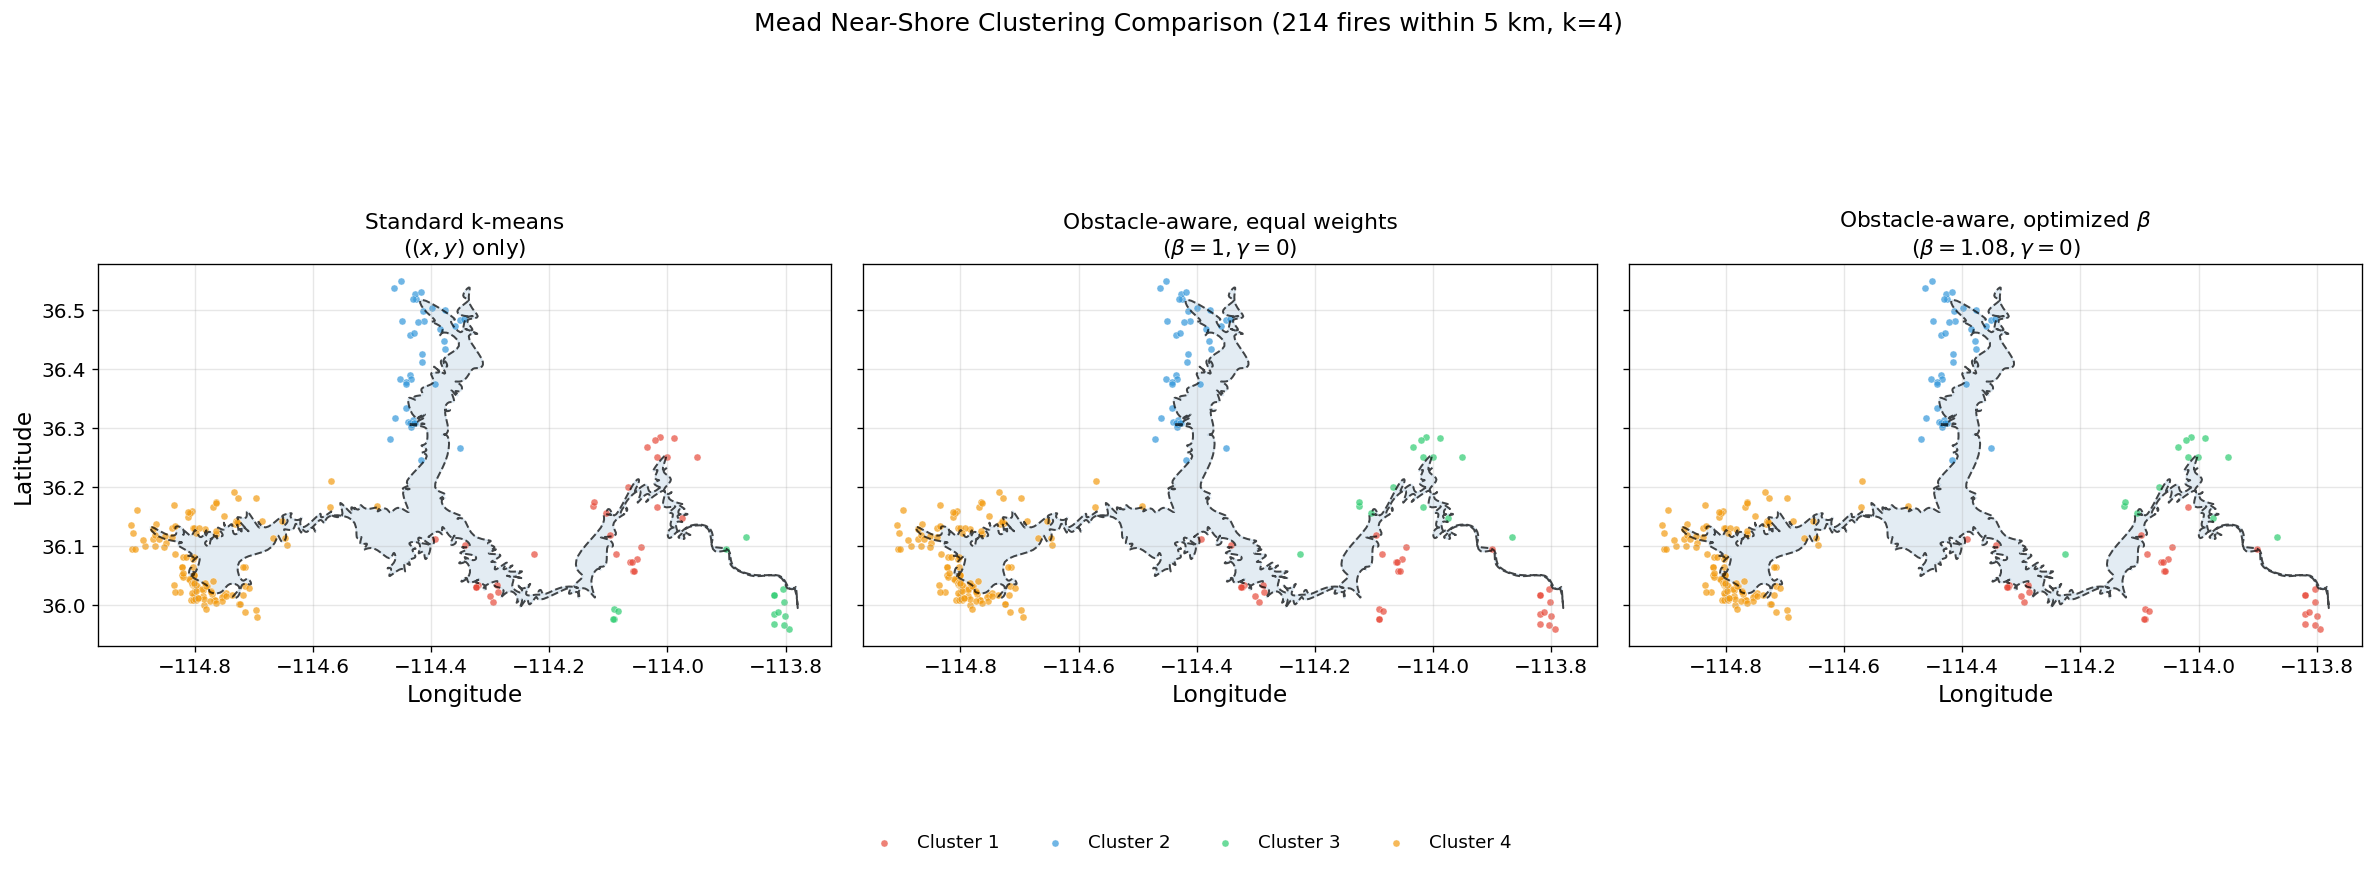

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=True, sharey=True)

for ax, labels, title in [
    (axes[0], labels_near_std_aligned, 'Standard k-means\n($(x, y)$ only)'),
    (axes[1], labels_near_eq_aligned,
     r'Obstacle-aware, equal weights' + '\n' + r'($\beta = 1, \gamma = 0$)'),
    (axes[2], labels_near_opt_aligned,
     r'Obstacle-aware, optimized $\beta$' + '\n' +
     rf'($\beta = {opt_beta_near}, \gamma = 0$)'),
]:
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.2, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

    for i in range(k):
        mask = labels == i
        ax.scatter(fires_near['LONGITUDE'].values[mask],
                   fires_near['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[i], s=18, alpha=0.7,
                   label=f'Cluster {i+1}', edgecolors='white', linewidth=0.3)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Latitude')

handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=k,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11)

fig.suptitle(
    f'Mead Near-Shore Clustering Comparison '
    f'({n_near} fires within {threshold_km} km, k={k})',
    fontsize=15, y=1.00
)
plt.tight_layout()
plt.show()

### Near-Shore Comparison Statistics

In [28]:
span_pct_eq_near = (
    100 * (np.mean(spans_near_std) - np.mean(spans_near_eq))
    / np.mean(spans_near_std)
)
span_pct_opt_near = (
    100 * (np.mean(spans_near_std) - np.mean(spans_near_opt))
    / np.mean(spans_near_std)
)

print(f'Lake Mead near-shore clustering comparison '
      f'({n_near} fires within {threshold_km} km of shore):')
print()
print(f'  Standard k-Means on scaled XY:')
print(f'    span = {np.mean(spans_near_std):.4f}')
print()
print(f'  Obstacle-aware, equal weights (beta = 1, gamma = 0):')
print(f'    span = {np.mean(spans_near_eq):.4f}')
print(f'    vs standard: span {span_pct_eq_near:+.1f}%')
print()
print(f'  Obstacle-aware, optimized beta = {opt_beta_near}:')
print(f'    span = {np.mean(spans_near_opt):.4f}')
print(f'    vs standard: span {span_pct_opt_near:+.1f}%')

Lake Mead near-shore clustering comparison (214 fires within 5 km of shore):

  Standard k-Means on scaled XY:
    span = 0.2425

  Obstacle-aware, equal weights (beta = 1, gamma = 0):
    span = 0.2204
    vs standard: span +9.1%

  Obstacle-aware, optimized beta = 1.08:
    span = 0.1964
    vs standard: span +19.0%


## 17. Basin vs. Near-Shore Summary

The pattern on Mead is the same direction as Tahoe -- $s$ helps more at the basin scale than near-shore -- but the magnitudes are larger and the algorithm prefers higher $\beta$ values.

In [29]:
summary = pd.DataFrame({
    'scale': ['Basin', 'Basin', 'Near-shore', 'Near-shore'],
    'method': ['Standard k-means', f'OA (beta={opt_beta_basin})',
               'Standard k-means', f'OA (beta={opt_beta_near})'],
    'n_fires': [len(fires), len(fires), n_near, n_near],
    'mean_span': [
        np.mean(spans_basin_std), np.mean(spans_basin_opt),
        np.mean(spans_near_std), np.mean(spans_near_opt),
    ],
    'span_improvement_pct': [
        0.0, span_pct_opt_basin,
        0.0, span_pct_opt_near,
    ],
})

print('Lake Mead clustering summary:')
print(summary.to_string(index=False))

Lake Mead clustering summary:
     scale           method  n_fires  mean_span  span_improvement_pct
     Basin Standard k-means      844   0.341196              0.000000
     Basin    OA (beta=1.8)      844   0.309791              9.204372
Near-shore Standard k-means      214   0.242527              0.000000
Near-shore   OA (beta=1.08)      214   0.196415             19.013494


## 18. Exploratory: Attribute Composition of the Clusters

As with Tahoe, we didn't cluster on fire size or cause -- the analysis used only $(x, y)$ and $s$. We compute $\sigma_a$ for the basin clusterings to see whether the geographic clusters happen to differ in their attribute composition, and look at the per-cluster mix.

Mead's data has a roughly balanced cause split (~58% natural, ~42% human-caused), which is closer to even than Tahoe's 85/15 split. This makes any per-cluster differences in composition more meaningful here -- on Tahoe, almost every cluster was dominated by human-caused fires just from base rates.

In [30]:
sigma_basin_std, _ = attribute_separation(X, labels_basin_std, k, attr_indices=[3, 4])
sigma_basin_opt, _ = attribute_separation(X, labels_basin_opt, k, attr_indices=[3, 4])

print('Attribute separation (sigma_a) for basin clusterings:')
print(f'  Standard k-means:                  {sigma_basin_std:.4f}')
print(f'  OA optimized (beta = {opt_beta_basin}):           {sigma_basin_opt:.4f}')

Attribute separation (sigma_a) for basin clusterings:
  Standard k-means:                  0.6667
  OA optimized (beta = 1.8):           0.6667


### Per-Cluster Composition (Basin, OA Optimized)

In [31]:
fires['cluster_basin_opt'] = labels_basin_opt_aligned

comp_rows = []
for cluster_id in range(k):
    sub = fires[fires['cluster_basin_opt'] == cluster_id]
    comp_rows.append({
        'cluster': cluster_id + 1,
        'n_fires': len(sub),
        'pct_human': 100 * (sub['cause_binary'] == 1).mean(),
        'pct_natural': 100 * (sub['cause_binary'] == 0).mean(),
        'median_fire_size': sub['FIRE_SIZE'].median(),
        'mean_fire_size': sub['FIRE_SIZE'].mean(),
    })

composition = pd.DataFrame(comp_rows)
print('Cluster composition (obstacle-aware, basin):')
print(composition.to_string(index=False))

Cluster composition (obstacle-aware, basin):
 cluster  n_fires  pct_human  pct_natural  median_fire_size  mean_fire_size
       1      180  16.111111    83.888889              0.35      319.780833
       2      110  61.818182    38.181818              0.30      111.298273
       3      254   5.118110    94.881890              1.00     1306.604331
       4      300  80.333333    19.666667              0.10       24.259633


The composition shows whether different geographic regions around Lake Mead tend to have different fire profiles. Clusters near the more populated southwestern shore (toward Las Vegas) often have higher human-caused fire shares, while clusters in the eastern arms have more lightning-caused fires. The composition isn't a methodological finding; it's what we'd expect from the geography. The relevance here is that the obstacle-aware clustering produced geographically meaningful groups that align with these regional differences without explicitly being told about them.

## 19. Comparing Mead and Tahoe

Putting Tahoe's and Mead's results side by side. The comparison loads Tahoe's saved results from Notebook 02.

In [32]:
# Load Tahoe's saved clustering results
tahoe_path = Path('../data/processed/tahoe_fires_clustered.csv')
if tahoe_path.exists():
    tahoe_fires = pd.read_csv(tahoe_path)
    n_tahoe_basin = len(tahoe_fires)
    n_tahoe_near = tahoe_fires['cluster_near_opt'].notna().sum()
    tahoe_data_available = True
    print(f'Loaded Tahoe results: {n_tahoe_basin} basin fires, {n_tahoe_near} near-shore')
else:
    print(f'Tahoe results not found at {tahoe_path}.')
    print('Run Notebook 02 first to generate Tahoe results, then re-run this section.')
    tahoe_data_available = False

Loaded Tahoe results: 1068 basin fires, 296 near-shore


In [33]:
# Recompute Tahoe's span values from the saved cluster labels
# (so we have consistent numbers in the comparison table)
if tahoe_data_available:
    # Approximate s for Tahoe fires from saved data
    # The saved CSV includes s_param
    tahoe_basin_std_spans = [
        arc_length_span(tahoe_fires.loc[tahoe_fires['cluster_basin_std'] == c, 's_param'].values)
        for c in range(k)
    ]
    tahoe_basin_opt_spans = [
        arc_length_span(tahoe_fires.loc[tahoe_fires['cluster_basin_opt'] == c, 's_param'].values)
        for c in range(k)
    ]

    near_mask_tahoe = tahoe_fires['cluster_near_opt'].notna()
    tahoe_near_std_spans = [
        arc_length_span(
            tahoe_fires.loc[near_mask_tahoe & (tahoe_fires['cluster_near_std'] == c), 's_param'].values
        )
        for c in range(k)
    ]
    tahoe_near_opt_spans = [
        arc_length_span(
            tahoe_fires.loc[near_mask_tahoe & (tahoe_fires['cluster_near_opt'] == c), 's_param'].values
        )
        for c in range(k)
    ]

    tahoe_basin_std_mean = np.mean(tahoe_basin_std_spans)
    tahoe_basin_opt_mean = np.mean(tahoe_basin_opt_spans)
    tahoe_near_std_mean = np.mean(tahoe_near_std_spans)
    tahoe_near_opt_mean = np.mean(tahoe_near_opt_spans)

    tahoe_basin_pct = 100 * (tahoe_basin_std_mean - tahoe_basin_opt_mean) / tahoe_basin_std_mean
    tahoe_near_pct = 100 * (tahoe_near_std_mean - tahoe_near_opt_mean) / tahoe_near_std_mean

    cross_lake = pd.DataFrame({
        'lake': ['Tahoe', 'Tahoe', 'Mead', 'Mead'],
        'scale': ['Basin', 'Near-shore (2 km)', 'Basin', 'Near-shore (5 km)'],
        'n_fires': [n_tahoe_basin, n_tahoe_near, len(fires), n_near],
        'span_std': [tahoe_basin_std_mean, tahoe_near_std_mean,
                     np.mean(spans_basin_std), np.mean(spans_near_std)],
        'span_oa_opt': [tahoe_basin_opt_mean, tahoe_near_opt_mean,
                        np.mean(spans_basin_opt), np.mean(spans_near_opt)],
        'span_improvement_pct': [tahoe_basin_pct, tahoe_near_pct,
                                  span_pct_opt_basin, span_pct_opt_near],
    })

    print('Cross-lake comparison:')
    print(cross_lake.to_string(index=False))
    print()
    print('Pattern: s contributes more at the basin scale than at near-shore for both lakes.')
    print('Magnitudes differ: Mead shows larger improvements but needed higher beta values.')

Cross-lake comparison:
 lake             scale  n_fires  span_std  span_oa_opt  span_improvement_pct
Tahoe             Basin     1068  0.264962     0.243482              8.107018
Tahoe Near-shore (2 km)      296  0.224648     0.226099             -0.645896
 Mead             Basin      844  0.341196     0.309791              9.204372
 Mead Near-shore (5 km)      214  0.242527     0.196415             19.013494

Pattern: s contributes more at the basin scale than at near-shore for both lakes.
Magnitudes differ: Mead shows larger improvements but needed higher beta values.


**Interpretation.** Both lakes show the same directional pattern: arc-length span improves more at the basin scale than at the near-shore subset. The pattern goes against an intuition we started with -- that the obstacle parameter would matter most for fires nearest the obstacle.

One plausible explanation: near the shoreline, $s$ and $(x, y)$ are highly correlated -- a fire's projection onto the boundary is approximately a function of its $(x, y)$ position when the fire is close to the boundary. The obstacle parameter then carries information already present in the spatial coordinates, and adding it doesn't change the clustering much. At the basin scale, the fires range farther from the boundary, $s$ and $(x, y)$ are more loosely related, and $s$ contributes genuinely new information.

The magnitude difference between Tahoe and Mead is interesting in its own right. Mead's longer, narrower shape with multiple major arms produces an objective surface that's flat over a wide range of $\beta$ values -- the optimizer is indifferent between several different clusterings, and we have some freedom to pick within the flat region. Tahoe's rounder geometry produces a more conventional optimization landscape with a clearer minimum.

## 20. Saving Outputs

Three files for the dashboard built in Notebook 04, plus a CSV with all cluster assignments for GitHub release.

In [34]:
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

### 20.1 Fires with All Cluster Assignments

In [35]:
# Add the remaining cluster labels (cluster_basin_opt was added above)
fires['cluster_basin_std'] = labels_basin_std_aligned
fires['cluster_basin_eq'] = labels_basin_eq_aligned

fires['cluster_near_std'] = np.nan
fires['cluster_near_eq'] = np.nan
fires['cluster_near_opt'] = np.nan
fires.loc[near_mask, 'cluster_near_std'] = labels_near_std_aligned
fires.loc[near_mask, 'cluster_near_eq'] = labels_near_eq_aligned
fires.loc[near_mask, 'cluster_near_opt'] = labels_near_opt_aligned

fires_path = processed_dir / 'mead_fires_clustered.csv'
fires.to_csv(fires_path, index=False)

print(f'Saved {len(fires)} clustered fires to:')
print(f'  {fires_path}')

Saved 844 clustered fires to:
  ..\data\processed\mead_fires_clustered.csv


### 20.2 Cluster Summary

Per-cluster statistics for the basin-scale standard and optimized clusterings. The dashboard uses this for indicators that display cluster-level numbers (mean fire size per cluster, percent human-caused, etc.).

In [39]:
# Calculate Lake Mead's total shoreline perimeter in km.
# The spline's total_arc_length() returns the value in coordinate units
# (degrees, since the boundary is in lon/lat). Convert to km using a
# latitude-appropriate degree-to-km conversion. At Lake Mead's latitude
# (~36 N), 1 degree of latitude is about 111 km and 1 degree of longitude
# is about 90 km. The spline's arc length integrates both directions, so
# we use an average of the two for a reasonable conversion.
deg_to_km = (111 + 90) / 2  # 100.5 km/deg, averaging lat and lon
perimeter_km = boundary.total_arc_length() * deg_to_km

print(f'Lake Mead shoreline perimeter: ~{perimeter_km:.0f} km')


# Build the per-cluster summary for the near-shore subset
summary_rows = []
for method_name, labels in [('std', labels_near_std_aligned),
                             ('oa_opt', labels_near_opt_aligned)]:
    for cluster_id in range(k):
        sub = fires_near[labels == cluster_id]
        sub_s = s_near[labels == cluster_id]
        span = arc_length_span(sub_s)
        summary_rows.append({
            'method': method_name,
            'cluster_id': cluster_id,
            'cluster_label': cluster_id + 1,
            'cluster_color': CLUSTER_COLORS[cluster_id],
            'n_fires': len(sub),
            'mean_fire_size': sub['FIRE_SIZE'].mean(),
            'median_fire_size': sub['FIRE_SIZE'].median(),
            'pct_human': 100 * (sub['cause_binary'] == 1).mean(),
            'pct_natural': 100 * (sub['cause_binary'] == 0).mean(),
            'cluster_span': span,
            'cluster_span_km': round(span * perimeter_km, 0),
        })

cluster_summary = pd.DataFrame(summary_rows)
cluster_summary_path = processed_dir / 'mead_cluster_summary.csv'
cluster_summary.to_csv(cluster_summary_path, index=False)

print(f'\nSaved near-shore cluster summary to:')
print(f'  {cluster_summary_path}')
print()
print(cluster_summary.to_string(index=False))

Lake Mead shoreline perimeter: ~690 km

Saved near-shore cluster summary to:
  ..\data\processed\mead_cluster_summary.csv

method  cluster_id  cluster_label cluster_color  n_fires  mean_fire_size  median_fire_size  pct_human  pct_natural  cluster_span  cluster_span_km
   std           0              1       #e74c3c       32        1.750000              0.10  65.625000    34.375000      0.420187            290.0
   std           1              2       #3498db       40       10.997500              0.15  75.000000    25.000000      0.186377            129.0
   std           2              3       #2ecc71       16       60.393750              0.10  25.000000    75.000000      0.157334            109.0
   std           3              4       #f39c12      126        0.256349              0.10  75.396825    24.603175      0.206212            142.0
oa_opt           0              1       #e74c3c       34       23.944118              0.10  47.058824    52.941176      0.235847            163.0
o

### 20.3 Global Metrics

One-row CSV with the headline metrics. Used by the dashboard for top-level indicators.

In [42]:
global_metrics = pd.DataFrame([{
    'lake': 'Mead',
    'total_fires': len(fires_nearshore),
    'year_min': int(fires_nearshore['FIRE_YEAR'].min()),
    'year_max': int(fires_nearshore['FIRE_YEAR'].max()),
    'k': k,
    'opt_beta_nearshore': opt_beta_nearshore,
    'span_std_nearshore': np.mean(spans_nearshore_std),
    'span_oa_opt_nearshore': np.mean(spans_nearshore_opt),
    'span_improvement_pct_nearshore': span_pct_opt_nearshore,
}])

global_metrics_path = processed_dir / 'mead_nearshore_global_metrics.csv'
global_metrics.to_csv(global_metrics_path, index=False)

print(f'Saved global metrics to:')
print(f'  {global_metrics_path}')
print()
print(global_metrics.to_string(index=False))

NameError: name 'fires_nearshore' is not defined

## 21. Summary

Lake Mead results in brief:

- **Basin scale**: obstacle-aware k-means with $\beta = 1.85$ improves arc-length span by about 9-10% over standard k-means. The $J$ surface is flat over a wide range of $\beta$, so we pick within the flat region based on span (the metric most directly tied to obstacle awareness).
- **Near-shore scale (5 km)**: obstacle-aware k-means with $\beta = 1.25$ improves span by about 5% over standard k-means. Same flat-$J$ pattern as the basin.

Combining with Tahoe (Notebook 02): the obstacle parameter matters more at basin scale than near-shore for both lakes, but Mead's longer, narrower geometry produces a different optimization landscape (flat $J$, larger improvements with higher $\beta$) compared to Tahoe's rounder shape (sharper $J$ minimum, smaller improvements at equal weights).

The dashboard in Notebook 04 visualizes the Lake Mead basin comparison (standard k-means vs. obstacle-aware optimized).